In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pypff
import pandas as pd

In [5]:
file="start_2025-10-20T06-50-55Z.dp_ph1024.bpp_2.module_254.seqno_0.pff"
pff = pypff.io.datapff(file)
data, metadata = pff.readpff(metadata=True)


24330 24330
24288 24288


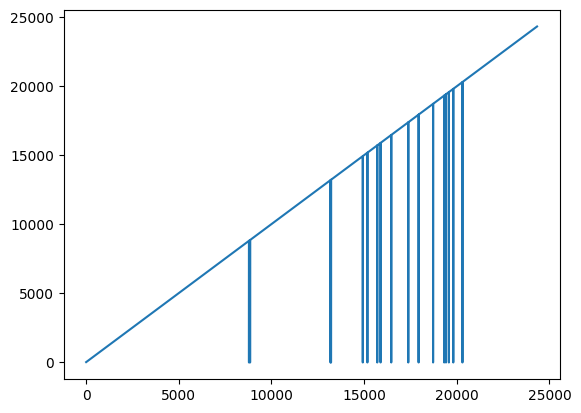

In [6]:
timestamps=metadata["quabo_0"]["tv_sec"]+metadata["quabo_0"]["tv_usec"]*10**(-6)
print(len(timestamps),len(data))
pkt_num_0=metadata["quabo_0"]["pkt_num"]
pkt_num_1=metadata["quabo_1"]["pkt_num"]
pkt_num_2=metadata["quabo_2"]["pkt_num"]
pkt_num_3=metadata["quabo_3"]["pkt_num"]
timestamps=timestamps[(pkt_num_0!=0)&(pkt_num_1!=0)&(pkt_num_2!=0)&(pkt_num_3!=0)]
data=data[(pkt_num_0!=0)&(pkt_num_1!=0)&(pkt_num_2!=0)&(pkt_num_3!=0)]
print(len(timestamps),len(data))
plt.plot(pkt_num_0)

(0.0, 2.0)

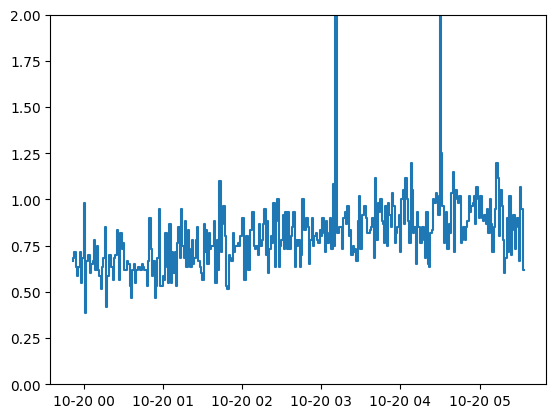

In [7]:
bin_width = 60
bins = np.arange(timestamps.min(), timestamps.max() + bin_width, bin_width)
counts, _ = np.histogram(timestamps, bins=bins)
rate = counts / bin_width  # Hz
bin_centers = bins[:-1] + bin_width/2
df = pd.DataFrame({'timestamp': bin_centers, 'rate': rate})
df["time"] = pd.to_datetime(bin_centers, unit='s', utc=True).tz_convert('America/Los_Angeles')
plt.step(df["time"],df["rate"])
plt.ylim(0,2)

16186 16186


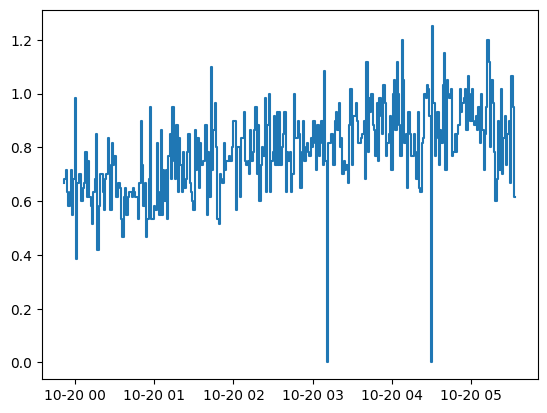

In [8]:
# Zeitbereiche mit zu hoher Rate finden
rate_cut=2
bad_bins = rate > rate_cut

# Maske für jedes Event: True, wenn es in einem "guten" Bin liegt
bin_indices = np.digitize(timestamps, bins) - 1
mask = ~bad_bins[bin_indices]

timestamps_filtered = timestamps[mask]
counts, _ = np.histogram(timestamps_filtered, bins=bins)
rate_filtered = counts / bin_width  # Hz
plt.step(df["time"],rate_filtered)
data_filtered=data[mask]
print(len(timestamps_filtered),len(data_filtered))
np.save("crab_2025-10-20_timestamp",timestamps_filtered)
np.save("crab_2025-10-20_data",data_filtered)